In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp

### Тестові функції

In [16]:
def rastrigin(x):
    A = 10
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

In [17]:
def mishra_bird(x):
    X, Y = x[0], x[1]
    term1 = np.sin(Y) * np.exp((1 - np.cos(X))**2)
    term2 = np.cos(X) * np.exp((1 - np.sin(Y))**2)
    return term1 + term2 + (X - Y)**2

In [18]:
# Точні координати глобальних мінімумів для розрахунку відстані
OPT_RASTRIGIN = np.zeros(20)
OPT_MISHRA_BIRD = np.array([-3.130246, -1.582142])

### Алгоритми ройового інтелекту

##### Алгоритм зграї зозуль

In [19]:
def cuckoo_search(obj_func, dim, bounds, max_iter=100, pop_size=25, p_detect=0.25, optimum=None):
    min_b, max_b = bounds
    
    # Ініціалізація популяції
    nests = np.random.uniform(min_b, max_b, (pop_size, dim))
    fitness = np.apply_along_axis(obj_func, 1, nests)
    
    best_idx = np.argmin(fitness)
    best_nest = nests[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    hist_fitness = []
    hist_distance = []
    
    for _ in range(max_iter):
        
        # 1. Польоти Леві (глобальний пошук)
        beta = 1.5
        sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
                 (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
        
        for i in range(pop_size):
            u = np.random.randn(dim) * sigma
            v = np.random.randn(dim)
            step = u / abs(v)**(1 / beta)
            
            stepsize = 0.01 * step * (nests[i] - best_nest)
            new_nest = nests[i] + stepsize * np.random.randn(dim)
            new_nest = np.clip(new_nest, min_b, max_b)
            
            new_fitness = obj_func(new_nest)
            if new_fitness < fitness[i]:
                nests[i] = new_nest
                fitness[i] = new_fitness
                
        # 2. Виявлення чужих яєць птахом-господарем (локальний пошук)
        for i in range(pop_size):
            if np.random.rand() < p_detect:
                step = np.random.rand() * (nests[np.random.randint(pop_size)] - nests[np.random.randint(pop_size)])
                new_nest = nests[i] + step
                new_nest = np.clip(new_nest, min_b, max_b)
                nests[i] = new_nest
                fitness[i] = obj_func(new_nest)
                
        # 3. Оновлення найкращого рішення
        current_best_idx = np.argmin(fitness)
        if fitness[current_best_idx] < best_fitness:
            best_fitness = fitness[current_best_idx]
            best_nest = nests[current_best_idx].copy()
            
        hist_fitness.append(best_fitness)
        
        if optimum is not None:
            dist = np.linalg.norm(best_nest - optimum)
            hist_distance.append(dist)
        
    return best_nest, best_fitness, hist_fitness, hist_distance

##### Алгоритм зграї кажанів

In [20]:
def bat_algorithm(obj_func, dim, bounds, max_iter=100, pop_size=20, optimum=None):
    min_b, max_b = bounds
    f_min, f_max = 0.0, 2.0
    
    # Ініціалізація популяції кажанів, швидкостей та параметрів
    bats = np.random.uniform(min_b, max_b, (pop_size, dim))
    velocities = np.zeros((pop_size, dim))
    fitness = np.apply_along_axis(obj_func, 1, bats)
    
    # Початкова гучність (A) та частота пульсацій (r)
    A = np.ones(pop_size)
    r = np.ones(pop_size) * 0.5
    
    best_idx = np.argmin(fitness)
    best_bat = bats[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    hist_fitness = []
    hist_distance = []
    
    for t in range(max_iter):
        for i in range(pop_size):
            
            # 1. Оновлення частоти, швидкості та нової позиції (Глобальний пошук)
            freq = f_min + (f_max - f_min) * np.random.rand()
            velocities[i] += (bats[i] - best_bat) * freq
            new_bat = bats[i] + velocities[i]
            
            # 2. Локальний пошук поблизу найкращого розв'язку (якщо випадкове число > r)
            if np.random.rand() > r[i]:
                new_bat = best_bat + 0.01 * np.random.randn(dim) * np.mean(A)
                
            new_bat = np.clip(new_bat, min_b, max_b)
            new_fitness = obj_func(new_bat)
            
            # 3. Прийняття нового розв'язку та оновлення гучності (A) і частоти (r)
            if (new_fitness < fitness[i]) and (np.random.rand() < A[i]):
                bats[i] = new_bat
                fitness[i] = new_fitness
                A[i] *= 0.9  # Зменшення гучності (кажан наближається до цілі)
                r[i] = r[i] * (1 - np.exp(-0.1 * t))  # Збільшення частоти випромінювання
                
            # 4. Оновлення глобального найкращого розв'язку
            if fitness[i] < best_fitness:
                best_fitness = fitness[i]
                best_bat = bats[i].copy()
                
        hist_fitness.append(best_fitness)
        
        if optimum is not None:
            dist = np.linalg.norm(best_bat - optimum)
            hist_distance.append(dist)
        
    return best_bat, best_fitness, hist_fitness, hist_distance 

### Метод стрільби

In [21]:
def shooting_objective(alpha_arr):
    alpha = alpha_arr[0]
    t0, tN, N = 1.0, 3.0, 100
    h = (tN - t0) / N
    u1, u2, u3 = alpha, 1.0, 1.0
    t = t0
    
    for _ in range(N):
        du3 = u3**4 + u1**3 - 3 * np.sin(t) * u2
        du2 = u1**2 * t**2 - (du3)**2 * np.cos(u2)
        du1 = u2
        
        u1 += h * du1
        u2 += h * du2
        u3 += h * du3
        
        if abs(u1) > 1e5 or abs(u3) > 1e5:
            return 1e6 
        t += h
        
    return abs(u1 - 2.0)

### Візуалізація та анліз роботи алгоритмів

In [22]:
# --- Растрігін ---
best_nest_r, fit_r_cs, fit_hist_r_cs, dist_hist_r_cs = cuckoo_search(
    rastrigin, dim=20, bounds=(-5.12, 5.12), max_iter=300, optimum=OPT_RASTRIGIN)
best_bat_r, fit_r_bat, fit_hist_r_bat, dist_hist_r_bat = bat_algorithm(
    rastrigin, dim=20, bounds=(-5.12, 5.12), max_iter=300, optimum=OPT_RASTRIGIN)

# Виведення результатів для функції Растрігіна
print("--- Результати оптимізації функції Растрігіна (n=20) ---")

print("\n1. Алгоритм Зозуль (Cuckoo Search):")
print(f"   Найкраще знайдене значення f(x) (Пристосовність): {fit_r_cs:.6f}")
print(f"   Кінцева відстань до ідеального оптимуму: {dist_hist_r_cs[-1]:.6f}")
print(f"   Знайдені координати (перші 5): {np.round(best_nest_r[:5], 6)}")

print("\n2. Алгоритм Кажанів (Bat Algorithm):")
print(f"   Найкраще знайдене значення f(x) (Пристосовність): {fit_r_bat:.6f}")
print(f"   Кінцева відстань до ідеального оптимуму: {dist_hist_r_bat[-1]:.6f}")
print(f"   Знайдені координати (перші 5): {np.round(best_bat_r[:5], 6)}")

--- Результати оптимізації функції Растрігіна (n=20) ---

1. Алгоритм Зозуль (Cuckoo Search):
   Найкраще знайдене значення f(x) (Пристосовність): 163.017446
   Кінцева відстань до ідеального оптимуму: 4.028154
   Знайдені координати (перші 5): [-1.911415 -0.040751  0.139616  0.017922 -0.963389]

2. Алгоритм Кажанів (Bat Algorithm):
   Найкраще знайдене значення f(x) (Пристосовність): 163.389813
   Кінцева відстань до ідеального оптимуму: 10.196628
   Знайдені координати (перші 5): [ 0.983599  4.02966  -0.011249  0.259526  1.001136]


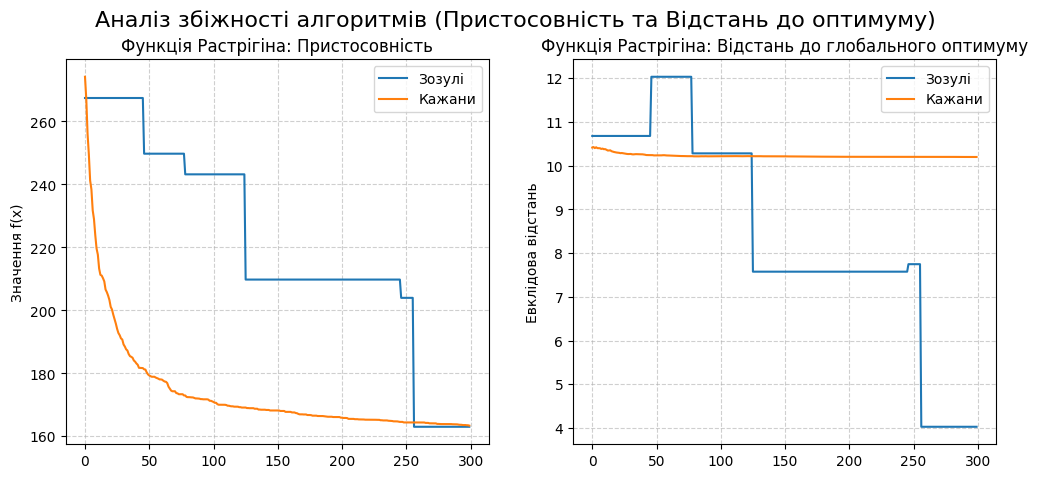

In [23]:
# --- Візуалізація ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Аналіз збіжності алгоритмів (Пристосовність та Відстань до оптимуму)', fontsize=16)

# 1. Пристосовність: Растрігін
axs[0].plot(fit_hist_r_cs, label='Зозулі')
axs[0].plot(fit_hist_r_bat, label='Кажани')
axs[0].set_title('Функція Растрігіна: Пристосовність')
axs[0].set_ylabel('Значення f(x)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# 2. Відстань: Растрігін
axs[1].plot(dist_hist_r_cs, label='Зозулі')
axs[1].plot(dist_hist_r_bat, label='Кажани')
axs[1].set_title('Функція Растрігіна: Відстань до глобального оптимуму')
axs[1].set_ylabel('Евклідова відстань')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

In [24]:
# --- Мішра-Берд ---
best_nest_mb, fit_mb_cs, fit_hist_mb_cs, dist_hist_mb_cs = cuckoo_search(
    mishra_bird, dim=2, bounds=(-10, 0), max_iter=150, optimum=OPT_MISHRA_BIRD)
best_bat_mb, fit_mb_bat, fit_hist_mb_bat, dist_hist_mb_bat = bat_algorithm(
    mishra_bird, dim=2, bounds=(-10, 0), max_iter=150, optimum=OPT_MISHRA_BIRD)

# Виведення результатів для функції Мішри-Берда
print("\n--- Результати оптимізації функції Мішри-Берда (n=2) ---")

print("\n1. Алгоритм Зозуль (Cuckoo Search):")
print(f"   Найкраще знайдене значення f(x, y) (Пристосовність): {fit_mb_cs:.6f}")
print(f"   Кінцева відстань до ідеального оптимуму: {dist_hist_mb_cs[-1]:.6f}")
print(f"   Знайдені координати (X, Y): {np.round(best_nest_mb, 6)}")

print("\n2. Алгоритм Кажанів (Bat Algorithm):")
print(f"   Найкраще знайдене значення f(x, y) (Пристосовність): {fit_mb_bat:.6f}")
print(f"   Кінцева відстань до ідеального оптимуму: {dist_hist_mb_bat[-1]:.6f}")
print(f"   Знайдені координати (X, Y): {np.round(best_bat_mb, 6)}")


--- Результати оптимізації функції Мішри-Берда (n=2) ---

1. Алгоритм Зозуль (Cuckoo Search):
   Найкраще знайдене значення f(x, y) (Пристосовність): -104.229708
   Кінцева відстань до ідеального оптимуму: 9.022411
   Знайдені координати (X, Y): [-9.518384 -7.953609]

2. Алгоритм Кажанів (Bat Algorithm):
   Найкраще знайдене значення f(x, y) (Пристосовність): -86.985913
   Кінцева відстань до ідеального оптимуму: 6.189050
   Знайдені координати (X, Y): [-3.179577 -7.770995]


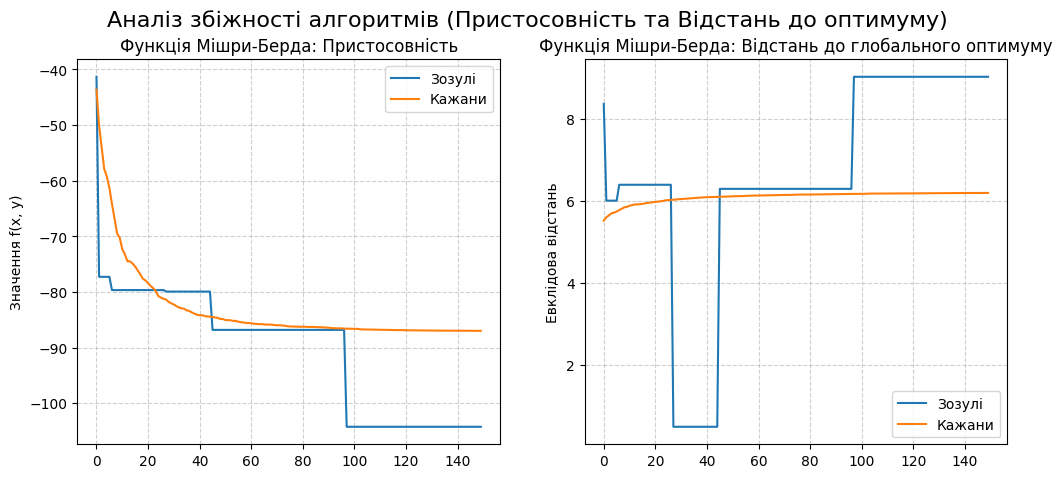

In [25]:
# --- Візуалізація ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Аналіз збіжності алгоритмів (Пристосовність та Відстань до оптимуму)', fontsize=16)

# 3. Пристосовність: Мішра-Берд
axs[0].plot(fit_hist_mb_cs, label='Зозулі')
axs[0].plot(fit_hist_mb_bat, label='Кажани')
axs[0].set_title('Функція Мішри-Берда: Пристосовність')
axs[0].set_ylabel('Значення f(x, y)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# 4. Відстань: Мішра-Берд
axs[1].plot(dist_hist_mb_cs, label='Зозулі')
axs[1].plot(dist_hist_mb_bat, label='Кажани')
axs[1].set_title('Функція Мішри-Берда: Відстань до глобального оптимуму')
axs[1].set_ylabel('Евклідова відстань')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

In [ ]:
def get_end_x(alpha):
    """Повертає кінцеве значення x(3) з перевіркою на переповнення"""
    t0, b, N = 1.0, 3.0, 500
    h = (b - t0) / N
    u1, u2, u3 = alpha, 1.0, 1.0
    t = t0
    
    threshold = 1e6 
    
    for _ in range(N):
        try:
            # Обчислюємо похідні частинами
            du3 = u3**4 + u1**3 - 3 * np.sin(t) * u2
            du2 = u1**2 * t**2 - (du3**2) * np.cos(u2)
            du1 = u2
            
            u1 += h * du1
            u2 += h * du2
            u3 += h * du3
            t += h
            
            if abs(u1) > threshold or abs(u2) > threshold or abs(u3) > threshold:
                return 1e10
                
        except OverflowError:
            return 1e10
            
    if np.isnan(u1) or np.isinf(u1):
        return 1e10
        
    return u1

In [ ]:
# Цільові функції
def objective_a(params):
    alpha = params[0]
    B = 2.0
    x_end = get_end_x(alpha)
    if x_end == 1e10: return 1e10
    return abs(x_end - B)

def objective_b(params):
    alpha = params[0]
    B = 2.0
    x_end = get_end_x(alpha)
    if x_end == 1e10: return 1e10
    return (x_end - B)**2

In [ ]:
# --- Виконання оптимізації ---
bounds_alpha = (-3.0, 3.0) 

# Запуск алгоритмів для функції А (модуль)
best_a_cs, fit_a_cs, hist_a_cs, _ = cuckoo_search(objective_a, dim=1, bounds=bounds_alpha, max_iter=100)
best_a_bat, fit_a_bat, hist_a_bat, _ = bat_algorithm(objective_a, dim=1, bounds=bounds_alpha, max_iter=100)

# Запуск алгоритмів для функції Б (квадрат)
best_b_cs, fit_b_cs, hist_b_cs, _ = cuckoo_search(objective_b, dim=1, bounds=bounds_alpha, max_iter=100)
best_b_bat, fit_b_bat, hist_b_bat, _ = bat_algorithm(objective_b, dim=1, bounds=bounds_alpha, max_iter=100)

print("--- Результати (Функція А: Модуль) ---")
print(f"Зозулі: alpha = {best_a_cs[0]:.6f}, f(a) = {fit_a_cs:.6e}")
print(f"Кажани: alpha = {best_a_bat[0]:.6f}, f(a) = {fit_a_bat:.6e}")

print("\n--- Результати (Функція B: Квадрат) ---")
print(f"Зозулі: alpha = {best_b_cs[0]:.6f}, f(b) = {fit_b_cs:.6e}")
print(f"Кажани: alpha = {best_b_bat[0]:.6f}, f(b) = {fit_b_bat:.6e}")

--- Результати (Функція А: Модуль) ---
Зозулі: alpha = 0.054553, f(a) = 1.417501e-01
Кажани: alpha = 0.043589, f(a) = 1.221987e-05

--- Результати (Функція B: Квадрат) ---
Зозулі: alpha = 0.043354, f(b) = 9.079154e-06
Кажани: alpha = -1.459667, f(b) = 1.955458e-08


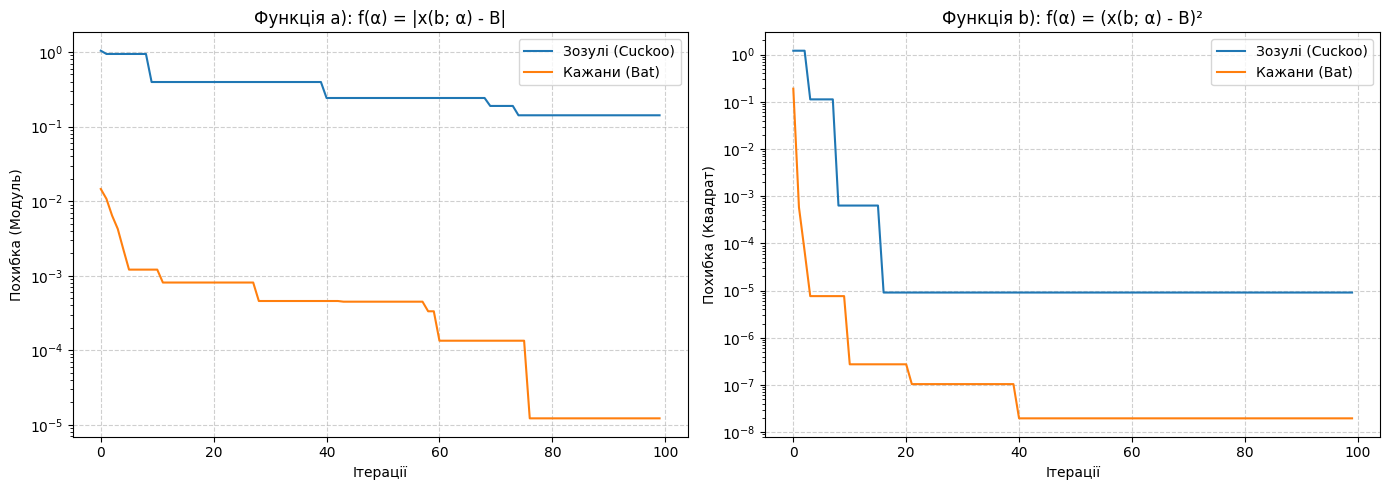

In [29]:
# --- Візуалізація збіжності для порівняння ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Збіжність для функції a) (Модуль)
axs[0].plot(hist_a_cs, label='Зозулі (Cuckoo)')
axs[0].plot(hist_a_bat, label='Кажани (Bat)')
axs[0].set_title("Функція a): f(α) = |x(b; α) - B|")
axs[0].set_xlabel("Ітерації")
axs[0].set_ylabel("Похибка (Модуль)")
axs[0].set_yscale('log')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Графік 2: Збіжність для функції b) (Квадрат)
axs[1].plot(hist_b_cs, label='Зозулі (Cuckoo)')
axs[1].plot(hist_b_bat, label='Кажани (Bat)')
axs[1].set_title("Функція b): f(α) = (x(b; α) - B)²")
axs[1].set_xlabel("Ітерації")
axs[1].set_ylabel("Похибка (Квадрат)")
axs[1].set_yscale('log')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

plt.tight_layout()
plt.show()